# ARIMA Experiments — Walmart Store Sales Forecasting

ეს notebook ამზადებს **leakage-safe, per-series ARIMA ექსპერიმენტებს** Walmart Store Sales Forecasting პროექტისთვის.

მთავარი პრინციპები:

- თითოეული `(Store, Dept)` არის დამოუკიდებელი weekly time series;
- გამოიყენება იგივე საერთო `preprocessing.py`, baseline და WMAE, რაც სხვა მოდელებში;
- validation არის არსებული ბოლო 3 თვე / 14 კვირა;
- ARIMA order იცვლება მხოლოდ `EXPERIMENT` ცვლადით;
- ათასობით series-ის გამო ვიყენებთ სწრაფ `StatsForecast` იმპლემენტაციას და parallel execution-ს;
- მოკლე, მუდმივი ან წარუმატებელი series-ებისთვის გამოიყენება უსაფრთხო fallback;
- ყველა run ილოგება MLflow / DagsHub-ში;
- საბოლოო section სრულ train-ზე აგენერირებს Kaggle-ის 39-კვირიან submission-ს.

> ARIMA არ იყენებს დამატებით Walmart feature-ებს. ის პროგნოზს აკეთებს მხოლოდ target-ის წარსული მნიშვნელობებით.


## 1. Setup repository, paths, and packages

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os
import sys
import subprocess

REPO_URL = "https://github.com/IrakliZerekidze/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting.git"
REPO_DIR = Path("/content/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=True)

os.chdir(REPO_DIR)
sys.path.insert(0, str(REPO_DIR))

print("Working directory:", Path.cwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting


In [ ]:
!pip install -q statsforecast mlflow dagshub pyarrow

## 2. Download Kaggle data if needed

In [ ]:
DATA_DIR = REPO_DIR / "data" / "raw"
PROCESSED_DIR = REPO_DIR / "data" / "processed"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

required_files = [
    DATA_DIR / "train.csv.zip",
    DATA_DIR / "test.csv.zip",
    DATA_DIR / "features.csv.zip",
    DATA_DIR / "stores.csv",
]

if not all(p.exists() for p in required_files):
    print("Raw Kaggle files not found. Upload kaggle.json when prompted.")
    from google.colab import files
    files.upload()

    Path.home().joinpath(".kaggle").mkdir(exist_ok=True)
    subprocess.run(["cp", "kaggle.json", str(Path.home() / ".kaggle" / "kaggle.json")], check=True)
    subprocess.run(["chmod", "600", str(Path.home() / ".kaggle" / "kaggle.json")], check=True)

    subprocess.run([
        "kaggle", "competitions", "download",
        "-c", "walmart-recruiting-store-sales-forecasting",
        "-p", str(DATA_DIR)
    ], check=True)

    subprocess.run([
        "unzip", "-o",
        str(DATA_DIR / "walmart-recruiting-store-sales-forecasting.zip"),
        "-d", str(DATA_DIR)
    ], check=True)
else:
    print("Raw Kaggle files already exist. Skipping download.")

Raw Kaggle files already exist. Skipping download.


## 3. Run or load common preprocessing

In [ ]:
import importlib
import preprocessing
importlib.reload(preprocessing)

from preprocessing import run_pipeline, load_processed, weighted_mae

processed_files = [
    PROCESSED_DIR / "train_part.parquet",
    PROCESSED_DIR / "valid_part.parquet",
    PROCESSED_DIR / "train_full.parquet",
    PROCESSED_DIR / "test_full.parquet",
]

FORCE_REPROCESS = False

if FORCE_REPROCESS or not all(path.exists() for path in processed_files):
    print("Running common preprocessing from scratch...")

    for path in processed_files:
        if path.exists():
            path.unlink()

    train_part, valid_part, train_full, test_full = run_pipeline(
        data_dir=DATA_DIR,
        out_dir=PROCESSED_DIR,
        months_valid=3,
        save=True,
    )
else:
    print("Loading existing processed parquet files...")
    train_part, valid_part, train_full, test_full = load_processed(PROCESSED_DIR)

print("train_part:", train_part.shape)
print("valid_part:", valid_part.shape)
print("train_full:", train_full.shape)
print("test_full:", test_full.shape)

print(
    "Validation dates:",
    valid_part["Date"].min(),
    "→",
    valid_part["Date"].max(),
)
print("Validation unique weeks:", valid_part["Date"].nunique())
print("Kaggle test unique weeks:", test_full["Date"].nunique())

Loading existing processed parquet files...
train_part: (428409, 33)
valid_part: (41463, 32)
train_full: (476333, 33)
test_full: (115064, 29)
Validation dates: 2012-07-27 00:00:00 → 2012-10-26 00:00:00
Validation unique weeks: 14
Kaggle test unique weeks: 39


## 4. Choose one ARIMA experiment

ARIMA order არის `(p, d, q)`:

- `p` — რამდენი წინა target lag გამოიყენება;
- `d` — რამდენჯერ კეთდება differencing;
- `q` — რამდენი წინა forecast error გამოიყენება.

პროფესორის მითითების შესაბამისად მხოლოდ რამდენიმე მცირე, თეორიულად დასაბუთებულ order-ს ვამოწმებთ.


In [ ]:
CONFIG = {
    "experiment": "arima_201",
    "order": (2, 0, 1),
    "horizon": int(valid_part["Date"].nunique()),
    "freq": "W-FRI",
    "target_col": "Weekly_Sales",
    "evaluation_target_col": "Weekly_Sales",
    "season_length": 1,
    "n_jobs": -1,
    "stepwise": True,
    "approximation": True,

}

METADATA = {
    "model": "ARIMA",
    "model_type": "local_univariate",
    "description": "Without differencing",
    "missing_target_strategy": "linear_interpolation",
    "fallback_strategy": (
        "store_dept_then_dept_then_store_then_global_median"
    ),
}

EXPERIMENT = CONFIG["experiment"]

print("Selected configuration:")
for key, value in CONFIG.items():
    print(f"{key}: {value}")

print("\nMetadata:")
for key, value in METADATA.items():
    print(f"{key}: {value}")


Selected configuration:
experiment: arima_201
order: (2, 0, 1)
horizon: 14
freq: W-FRI
target_col: Weekly_Sales
evaluation_target_col: Weekly_Sales
season_length: 1
n_jobs: -1
stepwise: True
approximation: True

Metadata:
model: ARIMA
model_type: local_univariate
description: Without differencing
missing_target_strategy: linear_interpolation
fallback_strategy: store_dept_then_dept_then_store_then_global_median


## 5. Convert data to StatsForecast format

In [ ]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple


def fill_missing_target_per_series(
    df: pd.DataFrame,
    target_col: str,
) -> pd.DataFrame:
    """Fill only grid-created target gaps using interpolation within each series."""
    result = df.copy()
    result = result.sort_values(["Store", "Dept", "Date"])

    result[target_col] = (
        result.groupby(["Store", "Dept"], group_keys=False)[target_col]
        .apply(lambda s: s.interpolate(method="linear", limit_direction="both"))
    )

    # Extremely short/all-missing series are handled with hierarchical medians.
    store_dept_median = result.groupby(["Store", "Dept"])[target_col].transform("median")
    dept_median = result.groupby("Dept")[target_col].transform("median")
    store_median = result.groupby("Store")[target_col].transform("median")
    global_median = result[target_col].median()

    result[target_col] = (
        result[target_col]
        .fillna(store_dept_median)
        .fillna(dept_median)
        .fillna(store_median)
        .fillna(global_median)
    )

    return result


def make_statsforecast_df(
    df: pd.DataFrame,
    target_col: str,
) -> pd.DataFrame:
    prepared = fill_missing_target_per_series(df, target_col)

    prepared["unique_id"] = (
        prepared["Store"].astype(str)
        + "_"
        + prepared["Dept"].astype(str)
    )

    sf_df = prepared.rename(
        columns={"Date": "ds", target_col: "y"}
    )[["unique_id", "ds", "y"]].copy()

    sf_df["ds"] = pd.to_datetime(sf_df["ds"])
    sf_df["y"] = pd.to_numeric(sf_df["y"], errors="coerce")
    sf_df = sf_df.dropna(subset=["y"])

    sf_df = (
        sf_df.sort_values(["unique_id", "ds"])
        .drop_duplicates(["unique_id", "ds"], keep="last")
        .reset_index(drop=True)
    )

    return sf_df


train_sf = make_statsforecast_df(
    train_part,
    target_col=CONFIG["target_col"],
)

print(train_sf.head())
print("Rows:", len(train_sf))
print("Series:", train_sf["unique_id"].nunique())
print("Date range:", train_sf["ds"].min(), "→", train_sf["ds"].max())
print("Missing y:", train_sf["y"].isna().sum())

series_lengths = train_sf.groupby("unique_id").size()
print(series_lengths.describe())

  unique_id         ds         y
0      10_1 2010-02-05  40212.84
1      10_1 2010-02-12  67699.32
2      10_1 2010-02-19  49748.33
3      10_1 2010-02-26  33601.22
4      10_1 2010-03-05  36572.44
Rows: 428409
Series: 3321
Date range: 2010-02-05 00:00:00 → 2012-07-20 00:00:00
Missing y: 0
count    3321.0
mean      129.0
std         0.0
min       129.0
25%       129.0
50%       129.0
75%       129.0
max       129.0
dtype: float64


## 6. Store–Department median baseline

In [ ]:
def add_identifiers(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result["unique_id"] = (
        result["Store"].astype(str)
        + "_"
        + result["Dept"].astype(str)
    )
    result["ds"] = pd.to_datetime(result["Date"])
    return result


def add_hierarchical_fallback(
    eval_df: pd.DataFrame,
    train_df: pd.DataFrame,
    target_col: str,
) -> Tuple[pd.DataFrame, Dict]:
    result = eval_df.copy()
    missing_before = result["pred"].isna()
    missing_rows = int(missing_before.sum())
    unseen_series = int(
        result.loc[missing_before, "unique_id"].nunique()
    )

    if missing_rows == 0:
        return result, {
            "missing_prediction_rows_before_fallback": 0,
            "unseen_series_before_fallback": 0,
        }

    clean = train_df.dropna(subset=[target_col]).copy()

    store_dept_median = clean.groupby(
        ["Store", "Dept"]
    )[target_col].median()

    dept_median = clean.groupby("Dept")[target_col].median()
    store_median = clean.groupby("Store")[target_col].median()
    global_median = float(clean[target_col].median())

    fallback_values = []

    for row in result.loc[missing_before].itertuples():
        value = store_dept_median.get(
            (row.Store, row.Dept),
            np.nan,
        )
        if pd.isna(value):
            value = dept_median.get(row.Dept, np.nan)
        if pd.isna(value):
            value = store_median.get(row.Store, np.nan)
        if pd.isna(value):
            value = global_median

        fallback_values.append(float(value))

    result.loc[missing_before, "pred"] = fallback_values

    return result, {
        "missing_prediction_rows_before_fallback": missing_rows,
        "unseen_series_before_fallback": unseen_series,
    }


def evaluate_predictions(
    eval_df: pd.DataFrame,
    target_col: str,
) -> Dict:
    usable = eval_df.dropna(
        subset=[target_col, "pred", "IsHoliday"]
    ).copy()

    if usable.empty:
        raise ValueError("No usable rows for evaluation.")

    overall = weighted_mae(
        usable[target_col].to_numpy(),
        usable["pred"].to_numpy(),
        usable["IsHoliday"].astype(bool).to_numpy(),
    )

    holiday = usable[usable["IsHoliday"].astype(bool)]
    nonholiday = usable[~usable["IsHoliday"].astype(bool)]

    holiday_wmae = (
        weighted_mae(
            holiday[target_col].to_numpy(),
            holiday["pred"].to_numpy(),
            holiday["IsHoliday"].astype(bool).to_numpy(),
        )
        if len(holiday)
        else np.nan
    )

    nonholiday_wmae = (
        weighted_mae(
            nonholiday[target_col].to_numpy(),
            nonholiday["pred"].to_numpy(),
            nonholiday["IsHoliday"].astype(bool).to_numpy(),
        )
        if len(nonholiday)
        else np.nan
    )

    return {
        "wmae": float(overall),
        "holiday_wmae": float(holiday_wmae),
        "nonholiday_wmae": float(nonholiday_wmae),
        "evaluation_rows": int(len(usable)),
    }


def make_store_dept_median_baseline(
    train_df: pd.DataFrame,
    actual_df: pd.DataFrame,
    target_col: str,
):
    medians = (
        train_df.dropna(subset=[target_col])
        .groupby(["Store", "Dept"])[target_col]
        .median()
        .rename("pred")
        .reset_index()
    )

    eval_df = add_identifiers(actual_df).merge(
        medians,
        on=["Store", "Dept"],
        how="left",
    )

    eval_df, fallback_info = add_hierarchical_fallback(
        eval_df,
        train_df=train_df,
        target_col=target_col,
    )

    metrics = evaluate_predictions(eval_df, target_col)

    return eval_df, metrics, fallback_info


baseline_eval, baseline_metrics, baseline_fallback = (
    make_store_dept_median_baseline(
        train_part,
        valid_part,
        target_col=CONFIG["evaluation_target_col"],
    )
)

print("Baseline valid WMAE:", baseline_metrics["wmae"])
print("Baseline holiday WMAE:", baseline_metrics["holiday_wmae"])
print("Baseline non-holiday WMAE:", baseline_metrics["nonholiday_wmae"])

Baseline valid WMAE: 2242.36541498678
Baseline holiday WMAE: 2516.237848954821
Baseline non-holiday WMAE: 2136.862955165337


## 7. Fit ARIMA and forecast validation

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import ARIMA
import time
import warnings
from statsforecast.models import AutoARIMA


warnings.filterwarnings("ignore")

p, d, q = CONFIG["order"]


model = AutoARIMA(
    season_length=1,
    stepwise=True,
    approximation=True,
    alias=EXPERIMENT,
)

sf = StatsForecast(
    models=[model],
    freq=CONFIG["freq"],
    n_jobs=CONFIG["n_jobs"],
)

print(
    f"Training {EXPERIMENT}: "
    f"ARIMA{CONFIG['order']} on "
    f"{train_sf['unique_id'].nunique()} series"
)

start_time = time.perf_counter()

forecast_df = sf.forecast(
    df=train_sf,
    h=CONFIG["horizon"],
)

training_seconds = time.perf_counter() - start_time

print(f"Completed in {training_seconds:.2f} seconds")
print(forecast_df.head())
print("Forecast rows:", len(forecast_df))
print("Forecast series:", forecast_df["unique_id"].nunique())


Training arima_201: ARIMA(2, 0, 1) on 3321 series
Completed in 990.58 seconds
  unique_id         ds     arima_201
0      10_1 2012-07-27  34300.247846
1      10_1 2012-08-03  39281.092470
2      10_1 2012-08-10  40493.105734
3      10_1 2012-08-17  40493.105734
4      10_1 2012-08-24  40493.105734
Forecast rows: 46494
Forecast series: 3321


## 8. Merge predictions with actual validation rows and evaluate

In [ ]:
prediction_column = EXPERIMENT

if prediction_column not in forecast_df.columns:
    candidate_columns = [
        col
        for col in forecast_df.columns
        if col not in ["unique_id", "ds"]
    ]
    if len(candidate_columns) != 1:
        raise ValueError(
            f"Could not identify forecast column. "
            f"Columns: {forecast_df.columns.tolist()}"
        )
    prediction_column = candidate_columns[0]

predictions = forecast_df.rename(
    columns={prediction_column: "pred"}
)[["unique_id", "ds", "pred"]].copy()

actual_valid = add_identifiers(valid_part)

valid_eval = actual_valid.merge(
    predictions,
    on=["unique_id", "ds"],
    how="left",
)

valid_eval, fallback_info = add_hierarchical_fallback(
    valid_eval,
    train_df=train_part,
    target_col=CONFIG["target_col"],
)

valid_eval["pred"] = valid_eval["pred"].clip(lower=0)

valid_metrics = evaluate_predictions(
    valid_eval,
    target_col=CONFIG["evaluation_target_col"],
)

improvement = baseline_metrics["wmae"] - valid_metrics["wmae"]
improvement_pct = 100 * improvement / baseline_metrics["wmae"]

print("\nARIMA validation results")
print("------------------------")
print(f"Order: {CONFIG['order']}")
print(f"Valid WMAE: {valid_metrics['wmae']:.4f}")
print(f"Holiday WMAE: {valid_metrics['holiday_wmae']:.4f}")
print(f"Non-holiday WMAE: {valid_metrics['nonholiday_wmae']:.4f}")
print(f"Baseline WMAE: {baseline_metrics['wmae']:.4f}")
print(f"Improvement: {improvement:.4f}")
print(f"Improvement %: {improvement_pct:.2f}%")
print(
    "Missing rows before fallback:",
    fallback_info["missing_prediction_rows_before_fallback"],
)
print(
    "Unseen series before fallback:",
    fallback_info["unseen_series_before_fallback"],
)


ARIMA validation results
------------------------
Order: (2, 0, 1)
Valid WMAE: 2139.4270
Holiday WMAE: 2361.0090
Non-holiday WMAE: 2054.0681
Baseline WMAE: 2242.3654
Improvement: 102.9384
Improvement %: 4.59%
Missing rows before fallback: 23
Unseen series before fallback: 10


In [ ]:
summary = pd.DataFrame(
    [
        {
            "experiment": EXPERIMENT,
            "order": str(CONFIG["order"]),
            "valid_wmae": valid_metrics["wmae"],
            "holiday_wmae": valid_metrics["holiday_wmae"],
            "nonholiday_wmae": valid_metrics["nonholiday_wmae"],
            "baseline_wmae": baseline_metrics["wmae"],
            "improvement": improvement,
            "improvement_pct": improvement_pct,
            "training_seconds": training_seconds,
            **fallback_info,
        }
    ]
)

display(summary)

,experiment,order,valid_wmae,holiday_wmae,nonholiday_wmae,baseline_wmae,improvement,improvement_pct,training_seconds,missing_prediction_rows_before_fallback,unseen_series_before_fallback
0,arima_201,"(2, 0, 1)",2139.427028,2361.009038,2054.068138,2242.365415,102.938387,4.590616,990.577993,23,10


## 9. Basic diagnostics on representative series

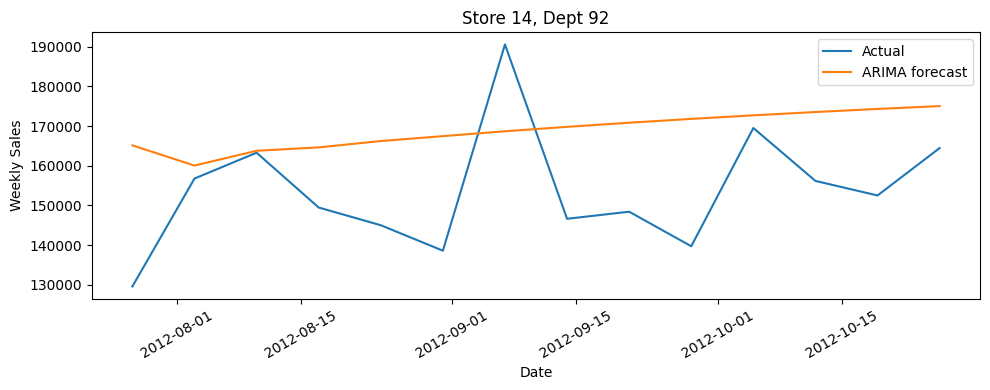

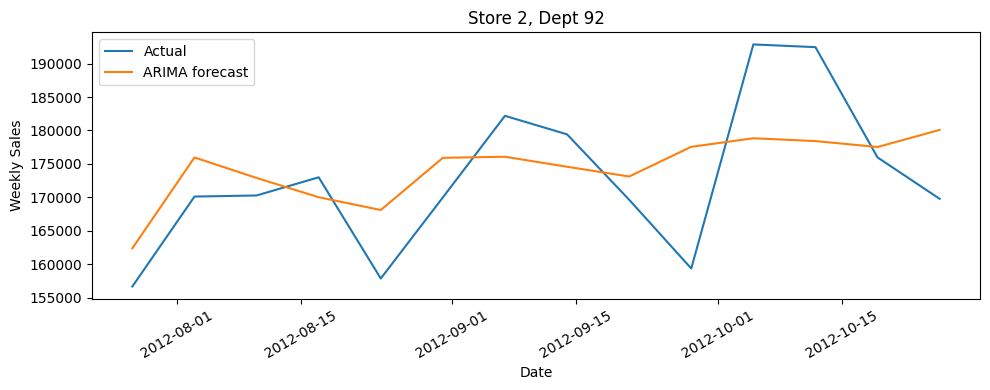

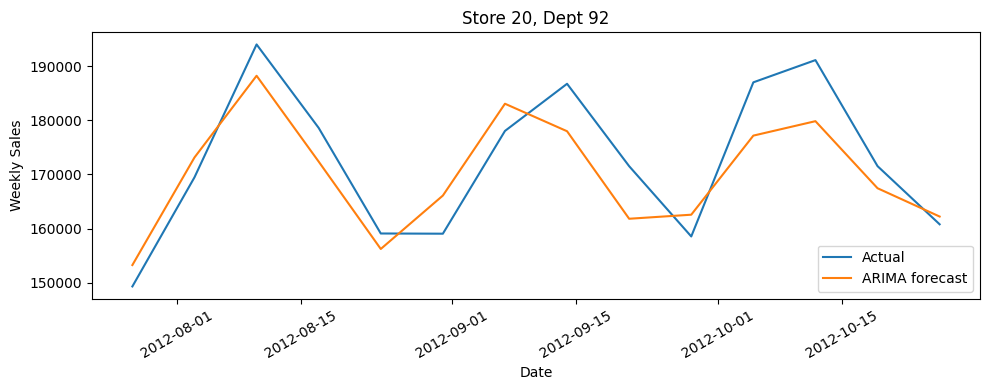

In [ ]:
import matplotlib.pyplot as plt

# Plot a few high-volume series for qualitative checking.
top_series = (
    train_part.dropna(subset=[CONFIG["target_col"]])
    .groupby(["Store", "Dept"])[CONFIG["target_col"]]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
    .tolist()
)

for store, dept in top_series:
    plot_df = valid_eval[
        (valid_eval["Store"] == store)
        & (valid_eval["Dept"] == dept)
    ].sort_values("Date")

    plt.figure(figsize=(10, 4))
    plt.plot(plot_df["Date"], plot_df[CONFIG["evaluation_target_col"]], label="Actual")
    plt.plot(plot_df["Date"], plot_df["pred"], label="ARIMA forecast")
    plt.title(f"Store {store}, Dept {dept}")
    plt.xlabel("Date")
    plt.ylabel("Weekly Sales")
    plt.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## 10. MLflow / DagsHub logging

In [ ]:
import dagshub
import mlflow

dagshub.init(
    repo_owner="izere23",
    repo_name="ML-Final-Walmart-Recruiting-Store-Sales-Forecasting",
    mlflow=True,
)

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment("ARIMA_Training")

print("MLflow tracking URI:", mlflow.get_tracking_uri())

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=214edff1-a652-4dba-81f8-c8095f529e0b&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=fdf1343db0c99add5b0646ff6999e94e4cd40af9e1b8f6fba855850c2a6d05bc




Accessing as gvakh23

Initialized MLflow to track repo "izere23/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting"

Repository izere23/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting initialized!

MLflow tracking URI: https://dagshub.com/izere23/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting.mlflow


In [ ]:
from pathlib import Path
import json

RUN_NAME = (
    f"ARIMA_order{p}{d}{q}"
    f"_h{CONFIG['horizon']}"
    f"_target_{CONFIG['target_col']}"
)

ARTIFACT_DIR = Path("artifacts") / RUN_NAME
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

valid_eval.to_csv(
    ARTIFACT_DIR / "valid_eval.csv",
    index=False,
)
predictions.to_csv(
    ARTIFACT_DIR / "valid_predictions.csv",
    index=False,
)
summary.to_csv(
    ARTIFACT_DIR / "metrics_summary.csv",
    index=False,
)

config_for_json = CONFIG.copy()
config_for_json["order"] = list(CONFIG["order"])

with open(ARTIFACT_DIR / "config.json", "w") as file:
    json.dump(config_for_json, file, indent=4)

with open(ARTIFACT_DIR / "metadata.json", "w") as file:
    json.dump(METADATA, file, indent=4)

if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name=RUN_NAME):
    # Descriptive metadata
    mlflow.log_param("model", METADATA["model"])
    mlflow.log_param("model_type", METADATA["model_type"])
    mlflow.log_param("description", METADATA["description"])
    mlflow.log_param(
        "missing_target_strategy",
        METADATA["missing_target_strategy"],
    )
    mlflow.log_param(
        "fallback_strategy",
        METADATA["fallback_strategy"],
    )

    # Training configuration
    mlflow.log_param("experiment", CONFIG["experiment"])
    mlflow.log_param("p", p)
    mlflow.log_param("d", d)
    mlflow.log_param("q", q)
    mlflow.log_param("order", str(CONFIG["order"]))
    mlflow.log_param("horizon", CONFIG["horizon"])
    mlflow.log_param("freq", CONFIG["freq"])
    mlflow.log_param("target_col", CONFIG["target_col"])
    mlflow.log_param(
        "evaluation_target_col",
        CONFIG["evaluation_target_col"],
    )
    mlflow.log_param("season_length", CONFIG["season_length"])
    mlflow.log_param("n_jobs", CONFIG["n_jobs"])

    mlflow.log_metric(
        "baseline_store_dept_median_wmae",
        baseline_metrics["wmae"],
    )
    mlflow.log_metric("valid_wmae", valid_metrics["wmae"])
    mlflow.log_metric(
        "holiday_wmae",
        valid_metrics["holiday_wmae"],
    )
    mlflow.log_metric(
        "nonholiday_wmae",
        valid_metrics["nonholiday_wmae"],
    )
    mlflow.log_metric("improvement_over_baseline", improvement)
    mlflow.log_metric(
        "improvement_over_baseline_pct",
        improvement_pct,
    )
    mlflow.log_metric("training_seconds", training_seconds)
    mlflow.log_metric(
        "missing_prediction_rows_before_fallback",
        fallback_info["missing_prediction_rows_before_fallback"],
    )
    mlflow.log_metric(
        "unseen_series_before_fallback",
        fallback_info["unseen_series_before_fallback"],
    )

    mlflow.log_artifacts(str(ARTIFACT_DIR))

print("Logged run:", RUN_NAME)


🏃 View run ARIMA_order201_h14_target_Weekly_Sales at: https://dagshub.com/izere23/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting.mlflow/#/experiments/5/runs/331feeb1708e44ccb434fa7cac33d214
🧪 View experiment at: https://dagshub.com/izere23/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting.mlflow/#/experiments/5
Logged run: ARIMA_order201_h14_target_Weekly_Sales


## 11. Final full-train model and Kaggle submission

ეს ნაწილი მხოლოდ მაშინ გაუშვი, როცა ARIMA order უკვე შეარჩიე.

მნიშვნელოვანი განსხვავება:

- validation horizon იყო 14 კვირა;
- Kaggle test horizon არის `test_full["Date"].nunique()`, ანუ 39 კვირა;
- final model თავიდან forecast-ს აკეთებს full train history-დან.


In [ ]:
RUN_FINAL_KAGGLE_INFERENCE = False

if not RUN_FINAL_KAGGLE_INFERENCE:
    print(
        "Final inference skipped. "
        "Set RUN_FINAL_KAGGLE_INFERENCE=True after selecting the best order."
    )

In [ ]:
if RUN_FINAL_KAGGLE_INFERENCE:
    final_train_sf = make_statsforecast_df(
        train_full,
        target_col=CONFIG["target_col"],
    )

    test_horizon = int(test_full["Date"].nunique())

    final_model = ARIMA(
        order=CONFIG["order"],
        season_length=CONFIG["season_length"],
        include_mean=(CONFIG["order"][1] == 0),
        alias=EXPERIMENT,
    )

    final_sf = StatsForecast(
        models=[final_model],
        freq=CONFIG["freq"],
        n_jobs=CONFIG["n_jobs"],
    )

    print(
        f"Forecasting {test_horizon} Kaggle test weeks "
        f"with ARIMA{CONFIG['order']}..."
    )

    final_start = time.perf_counter()

    final_forecast = final_sf.forecast(
        df=final_train_sf,
        h=test_horizon,
    )

    final_seconds = time.perf_counter() - final_start
    print(f"Final forecasting completed in {final_seconds:.2f} seconds")

    final_prediction_col = EXPERIMENT
    if final_prediction_col not in final_forecast.columns:
        candidate_columns = [
            col
            for col in final_forecast.columns
            if col not in ["unique_id", "ds"]
        ]
        final_prediction_col = candidate_columns[0]

    final_predictions = final_forecast.rename(
        columns={final_prediction_col: "Weekly_Sales"}
    )[["unique_id", "ds", "Weekly_Sales"]]

    test_for_merge = add_identifiers(test_full)

    submission_df = test_for_merge.merge(
        final_predictions,
        on=["unique_id", "ds"],
        how="left",
    )
    submission_for_fallback = submission_df.rename(
        columns={"Weekly_Sales": "pred"}
    )

    submission_for_fallback, final_fallback_info = (
        add_hierarchical_fallback(
            submission_for_fallback,
            train_df=train_full,
            target_col=CONFIG["target_col"],
        )
    )

    submission_for_fallback["pred"] = (
        submission_for_fallback["pred"].clip(lower=0)
    )

    submission = pd.DataFrame(
        {
            "Id": (
                submission_for_fallback["Store"].astype(str)
                + "_"
                + submission_for_fallback["Dept"].astype(str)
                + "_"
                + submission_for_fallback["Date"].dt.strftime("%Y-%m-%d")
            ),
            "Weekly_Sales": submission_for_fallback["pred"],
        }
    )

    submission_path = (
        ARTIFACT_DIR
        / f"submission_{EXPERIMENT}_h{test_horizon}.csv"
    )
    submission.to_csv(submission_path, index=False)

    display(submission.head())
    print("Submission shape:", submission.shape)
    print("Missing predictions:", submission["Weekly_Sales"].isna().sum())
    print("Saved to:", submission_path)